# 5. 自定义中间件
某些复杂场景下，官方内置的中间件不能完全满足需求，此时可以通过实现LangChain暴露的中间件hook函数 构建自定义中间件。

> 说明：尽可能使用内置中间件。

> **版本核对（2026-10-06）**：已对照本项目安装的 langchain 1.4.2、langgraph 1.2.12 的源码，以及官方文档 [Custom middleware](https://docs.langchain.com/oss/python/langchain/middleware/custom) 核对本笔记。PyPI 上的最新版本是 langchain 1.4.3、langgraph 1.2.14，这几个补丁版本没有改动自定义中间件的写法。
>
> 六个 hook、两类风格、装饰器和类两种写法都与当前版本一致。核对后补充或更正了以下几处：
> * 5.2：`before_model`、`after_model` 在每次调用模型前后都会执行，一次 `invoke` 中可能执行多次；`before_agent`、`after_agent` 每次 `invoke` 只执行一次。
> * 5.3.1 的示例直接修改了 state 中的消息对象。这样能运行，但官方的约定是通过返回值修改 state，见 5.3.4。
> * 5.3.1 类写法的规则：识别 hook 的是 LangChain 的 `create_agent`，不是 LangGraph；它看的是子类重写了哪些方法；第二个参数必须叫 `runtime`；类名会成为节点名的前缀，同一个 Agent 中不能重复。
> * 新增 5.3.2～5.3.7，解释 hook 的参数、返回值和 `AgentMiddleware`。

## 5.1 什么是hook函数(钩子函数)

Hook 函数，中文常叫 钩子函数 ，指的是：在某个既定流程的特定时机，被框架、系统或主程序 自动调用 的扩展函数。

> 因此，可以把它理解成：
> 主流程预留了一些插槽，允许你在这些位置挂上自己的函数，这种被挂进去并在特定时机执行的函数，就是 hook 函数。

核心特点：
1. 不是你主动在业务代码里随便调用的，而是当流程运行到某个“钩子点”时，系统自动触发它。
2. 它依附于一个更大的执行流程。比如“请求开始前”“模型调用前”“任务结束后”“异常发生时”等。
3. 它的作用是让你在不改主流程源码的前提下插入自己的逻辑。例如做 日志、鉴权、 修改输入、拦截输出、清理资源 等。

LangChain的中间件作用在Agent架构中，后者是基于LangGraph构建的流程图。

langchain存在六个hook函数（钩子函数）。

无论是官方内置中间件、自定义中间件、还是下文提到的便捷装饰器中间件，通常都是通过实现其中的一个或多个hook来生效的。

## 5.2 LangChain的hook函数分类

官方将六个钩子函数按照风格分为两类

类型1：Node-style hooks(节点风格钩子)

顾名思义，它们在流程的 特定节点 运行。准确地说，每个 node-style hook 本身就会成为 Agent 流程图中的一个节点（见 5.3.2）。

适合顺序逻辑，如记录日志、验证、更新状态

包括
* before_agent：在Agent开始运行之前执行，每次 `invoke` 只执行一次。
* before_model：在每次调用模型之前执行。Agent 执行完工具后会再次调用模型，所以一次 `invoke` 中可能执行多次。
* after_model：在每次模型返回之后执行，同样可能执行多次。
* after_agent：在Agent流程全部完成后执行，每次 `invoke` 只执行一次。

类型2：Wrap-style hooks(包装风格钩子)

顾名思义，它们 `包裹` 每一次模型或工具调用：调用前后都能插入逻辑，并且由 hook 决定这次调用执行 0 次（如命中缓存，直接返回结果）、1 次（正常执行）还是多次（如失败后重试）。

适合控制流，如重试、回退、缓存。

包括

* wrap_model_call (包裹模型调用)
* wrap_tool_call (包裹工具调用)

## 5.3 Node-style hooks函数用法
支持两种用法
* 装饰器是函数式挂载，把一个hook快速挂载到Agent的某个节点。
* 类写法是对象化中间件，把中间件封装为一个可配置、可复用、可扩展的组件。

两种写法本质相同：装饰器会自动生成一个 `AgentMiddleware` 的子类，并创建它的实例（见 5.3.5）。

### 5.3.1 基本用法
1. 基于装饰器实现

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.tools import tool
from pydantic import BaseModel, Field

load_dotenv(override=True, verbose=True, dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

model = ChatOpenAI(
    model="gpt-5.6-terra",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_API_BASE"],
    #profile=custom_profile
)

In [6]:
from langchain.agents.middleware import before_model, after_model, before_agent, after_agent
from typing import Any
from langgraph.runtime import Runtime
from langchain.agents import AgentState

@before_model
def before_model_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print("Before model middleware")
    state["messages"][-1].content += "----> before_model <-----\n"
    return None

@after_model
def after_model_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print("After model middleware")
    state["messages"][-1].content += "----> after_model <-----\n"
    return None

@before_agent
def before_agent_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print("Before agent middleware")
    state["messages"][-1].content += "----> before_agent <-----\n"
    return None

@after_agent
def after_agent_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print("After agent middleware")
    state["messages"][-1].content += "----> after_agent <-----\n"
    return None


In [7]:

from langchain_core.messages import HumanMessage


agent = create_agent(
    model=model,
    middleware=[before_model_middleware, after_model_middleware, before_agent_middleware, after_agent_middleware]
)

response = agent.invoke(
    {"messages":[HumanMessage(content="你好，请问你是谁？")]}
)

for msg in response["messages"]:
    msg.pretty_print()

Before agent middleware
Before model middleware
After model middleware
After agent middleware
================================ Human Message =================================

你好，请问你是谁？----> before_agent <-----
----> before_model <-----

================================== Ai Message ==================================

你好，我是 Codex，一个面向软件开发的 AI 助手。我可以帮你阅读和修改代码、排查问题、运行测试、解释技术概念，以及完成项目中的具体开发任务。----> after_model <-----
----> after_agent <-----


分析：

1. 执行顺序是 before_agent → before_model → after_model → after_agent，和 `middleware` 列表中的顺序（before_model、after_model、before_agent、after_agent）无关。不同种类的 hook 谁先谁后，由 Agent 的流程图固定（5.3.2）；列表顺序只决定同一种 hook 之间谁先谁后（5.3.6）。
2. before_agent、before_model 的标记加在了用户消息后面，after_model、after_agent 的标记加在了 AI 消息后面：before 类 hook 执行时，`state["messages"][-1]` 还是用户消息；after 类 hook 执行时，它已经是模型的回复。

> ⚠️ 这里为了直观，直接修改了 state 中消息对象的 `content`，然后返回 `None`。这样能看到效果，但不是推荐的写法。官方的约定是**通过返回值**修改 state，原因和推荐写法见 5.3.4。

2. 基于类的实现

关键规则：
1. 必须继承 AgentMiddleware ← 这个固定
2. 方法名固定 ( before_agent、before_model、after_model、after_agent ) ← 这个固定。拼错不会报错，但这个方法永远不会被执行
3. 方法参数照写 `(self, state: AgentState, runtime: Runtime)` ← 第二个参数名 `runtime` 不能改（原因见 5.3.3）
4. 类名随意 ← 这个不固定。但类名就是中间件的名字，会成为流程图中节点名的前缀（如 `MyMiddleware.before_model`），同一个 Agent 中不能重复

`create_agent` 只看（是它把中间件组装进 LangGraph 的流程图）：
* 是否继承 AgentMiddleware？
* 重写了哪几个 hook 方法？只有重写过的 hook 才会变成流程图中的节点

为什么这样规定，见 5.3.5。

In [8]:
from langchain.agents.middleware import AgentMiddleware

class MyMiddleware(AgentMiddleware):
    def before_model(self,state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += "----> before_model <-----"
        return None

    def after_model(self,state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += "----> after_model <-----"
        return None

    def before_agent(self,state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += "----> before_agent <-----"
        return None

    def after_agent(self,state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += "----> after_agent <-----"
        return None


In [10]:
my_middleware = MyMiddleware()

agent = create_agent(
    model=model,
    middleware=[my_middleware]
)


response = agent.invoke({
    "messages": [HumanMessage("你好,不要使用联网搜索，根据你的知识回答当前日本首相是谁?")]
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好,不要使用联网搜索，根据你的知识回答当前日本首相是谁?----> before_agent <---------> before_model <-----
================================== Ai Message ==================================

根据我掌握的最新可靠信息，日本首相是**石破茂（Shigeru Ishiba）**。他于 **2024年10月1日** 就任。日本首相可能因党内选举或政治变化而更替，因此“当前”信息建议以日本政府官方公告为准。----> after_model <---------> after_agent <-----


分析：效果和装饰器写法相同，区别是 4 个 hook 写在同一个类里，属于同一个中间件 `MyMiddleware`。代码中的标记字符串没有加 `\n`，所以连在了一起。

### 5.3.2 hook 是怎么被调用的：每个 hook 都是流程图中的一个节点

要弄清 hook 的参数和返回值为什么这样定义，先要知道 Agent 是怎么调用 hook 的。

**回顾（第七章 01 笔记 2.4）**：`create_agent` 返回的 Agent 是一张 LangGraph 流程图，由三样东西组成：
* **状态（state）**：在各个步骤之间传递的一份数据，主要是 `messages`（对话的消息列表），每一步都可以读取和更新它；
* **节点（node）**：一个步骤，本质是一个函数，如调用模型的 `model` 节点、执行工具的 `tools` 节点；
* **边（edge）**：决定下一步去哪个节点。

**加入中间件后**：`create_agent` 会把中间件实现的每个 node-style hook 也变成流程图中的一个节点，节点名是 `中间件名.hook名`，排在 `model` 节点的前后。这就是“节点风格”这个名字的由来。

下面只创建 Agent、查看流程图，不调用模型：

In [11]:
# 装饰器写法：5.3.1 中的 4 个中间件，每个只实现了 1 个 hook
agent_decorator = create_agent(
    model=model,
    middleware=[before_model_middleware, after_model_middleware, before_agent_middleware, after_agent_middleware],
)
print("装饰器写法的节点:", list(agent_decorator.get_graph().nodes))

# 类写法：1 个中间件实现了 4 个 hook
agent_class = create_agent(model=model, middleware=[MyMiddleware()])
print("类写法的节点:", list(agent_class.get_graph().nodes))

装饰器写法的节点: ['__start__', 'model', 'before_model_middleware.before_model', 'after_model_middleware.after_model', 'before_agent_middleware.before_agent', 'after_agent_middleware.after_agent', '__end__']
类写法的节点: ['__start__', 'model', 'MyMiddleware.before_agent', 'MyMiddleware.before_model', 'MyMiddleware.after_model', 'MyMiddleware.after_agent', '__end__']


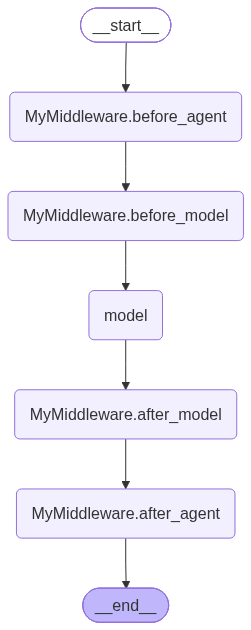

In [12]:
from IPython.display import Image, display

display(Image(agent_class.get_graph().draw_mermaid_png()))

分析：

1. 节点名都是 `中间件名.hook名`：装饰器写法的中间件名是函数名，类写法的中间件名是类名。
2. hook 节点和 `model` 节点首尾相连：`__start__` → before_agent → before_model → `model` → after_model → after_agent → `__end__`。有工具时，`tools` 节点执行完会回到 before_model，形成循环（见 5.3.6）。

**LangGraph 怎么执行一个节点**，可以简化成三步：

```python
update = 节点函数(state, runtime=runtime)   # ① 调用节点函数，传入当前的 state 和 runtime
if update is not None:
    state = 合并(state, update)              # ② 把返回的字典按规则合并进 state
# ③ 沿着边走到下一个节点，把合并后的 state 交给它
```

hook 就是这里的“节点函数”。它不是我们自己调用的，而是框架运行到这个节点时调用的（5.1 核心特点第 1 条）。所以 hook 的参数和返回值都由框架规定，就像插头必须按插座的规格来做：

* **参数**：框架调用时只会传入 `state` 和 `runtime` 两样东西 → 5.3.3
* **返回值**：框架只认 `None`（不修改）和字典（要修改的内容） → 5.3.4

### 5.3.3 参数：state 和 runtime

以 5.3.1 中的 `before_model_middleware` 为例：

```python
def before_model_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
```

框架调用它时传入两个参数：

| 参数 | 是什么 | 里面有什么 | 运行过程中会变吗 |
|---|---|---|---|
| `state` | Agent 当前的状态，也就是 5.3.2 中在节点之间传递的那份数据 | 默认只有 `messages`（对话的消息列表）；使用结构化输出时还有 `structured_response` | 会。每个节点都可能更新它，所以 `before_model` 每次看到的消息都比上一次多 |
| `runtime` | 本次运行的“运行环境”，存放不属于对话、但运行时可能用到的东西 | `context`：调用 Agent 时传入的上下文，如用户 id<br>`store`：长期记忆的存储（后面学）<br>`stream_writer`：发送自定义流式数据（第七章 08 笔记的 custom 模式） | `context` 在一次运行中保持不变 |

#### 1. state：AgentState 只是类型说明，运行时就是普通字典

`AgentState` 的源码（`langchain/agents/middleware/types.py`，简化）：

```python
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]   # 必有：消息列表，合并规则是 add_messages
    structured_response: NotRequired[...]                  # 可选：结构化输出的结果
    jump_to: NotRequired[...]                              # 可选：框架内部使用的跳转标记（见 5.3.4）
```

`AgentState` 是一个 `TypedDict`（第六章 04 笔记）：只说明“这个字典有哪些键、值是什么类型”，运行时传进来的 `state` 就是一个普通的 `dict`。所以读取方式和字典一样，例如 `state["messages"][-1]` 是最后一条消息，`len(state["messages"])` 是消息条数。

`messages` 类型中的 `add_messages` 是这个字段的**合并规则**（reducer），它决定了 hook 返回 `{"messages": [...]}` 时，新消息是追加还是替换（见 5.3.4）。

> `AgentState` 可以从 `langchain.agents` 导入（5.3.1 的写法），也可以从 `langchain.agents.middleware` 导入（官方文档的写法），两者是同一个类。

#### 2. runtime：存放 state 以外的运行信息

用户 id、数据库连接这类信息，在调用 Agent 之前就确定了，运行中不会变，也不属于对话内容，所以不放进 state，而是放在 `runtime` 里交给 hook。用法分三步：创建 Agent 时用 `context_schema` 声明上下文的结构，调用时用 `context=...` 传入，hook 中用 `runtime.context` 读取。完整例子见 5.3.4。

`Runtime[UserContext]` 这种写法中，方括号里的类型是告诉 IDE `runtime.context` 是什么类型，方便自动补全；不写方括号也能运行。

> `runtime` 还有 `execution_info`（当前节点的执行信息，如第几次重试）等属性，了解即可。

#### 3. 参数的写法规则

参数能不能改名，取决于框架怎么传参：

| 写法 | 框架怎么传参 | 规则 |
|---|---|---|
| 装饰器 | 按**位置**传：`你的函数(state, runtime)` | 必须能接收两个参数，名字随意。只写一个参数会报 `TypeError: ... takes 1 positional argument but 2 were given` |
| 类 | `state` 按位置传，`runtime` 按**名字**传：`中间件.before_model(state, runtime=runtime)` | 第一个参数名随意，第二个参数必须叫 `runtime`。改名（如 `rt`）会报 `TypeError: ... missing 1 required positional argument: 'rt'` |

* 装饰器内部为什么按位置传参，见 5.3.5。
* 类写法中，LangGraph 会先检查方法有没有名叫 `runtime` 的参数，有才传入。所以类写法不写 `runtime` 参数也能运行，但不能改名。
* 以上报错均在 langchain 1.4.2 中实测。最省事的做法是一律照官方写法 `(state: AgentState, runtime: Runtime)`，用不到 `runtime` 也写上。

参数后面的类型注解（`: AgentState`、`: Runtime`）Python 运行时不会检查，删掉也能运行。写上是为了让 IDE 能提示 `state`、`runtime` 里有什么，也方便读代码的人理解。

### 5.3.4 返回值：通过返回值更新 state

`-> dict[str, Any] | None` 表示返回值有两种：

| 返回值 | 含义 | 框架怎么处理 |
|---|---|---|
| `None` | 不修改 state | 什么都不做，直接进入下一个节点。函数末尾不写 `return`，也等于返回 `None` |
| 字典 | 要对 state 做的修改：键是 state 的字段名，值是新内容 | 按字段的合并规则合并进 state，再进入下一个节点 |

返回其他类型（如字符串）会报 `InvalidUpdateError: Expected dict, got ...`。和参数一样，`-> dict[str, Any] | None` 这个类型注解本身不会被检查，真正的检查发生在框架合并返回值的时候。

> 源码中 hook 还可以返回 LangGraph 的 `Command` 对象来控制流程，属于 LangGraph 的进阶用法，这里不展开。

#### 1. 字典怎么合并进 state

返回的字典只需要写**要修改的字段**，没写的字段保持不变。每个字段怎么合并，由 `AgentState` 中这个字段的合并规则决定。`messages` 的规则是 `add_messages`（第七章 04 笔记 7.1.1 中，`model` 节点返回的 `AIMessage` 就是这样追加进去的）：

| 返回 | 结果 |
|---|---|
| `{"messages": [新消息]}`，新消息的 `id` 和已有消息都不同（新建消息时不指定 `id` 就属于这种） | 追加到消息列表末尾 |
| `{"messages": [新消息]}`，新消息的 `id` 和某条已有消息相同 | 替换那条消息 |

所以返回 `{"messages": [...]}` 不会覆盖整个消息列表。没有合并规则的字段（如后面会学的自定义字段）则直接用新值覆盖旧值。

> 注意：返回 state 中不存在的键（如 `{"foo": 1}`）不会报错，但会被直接丢弃，后面的节点读不到。要增加自定义字段，需要扩展 state 的结构（`state_schema`，后面学）。

#### 2. 示例：通过返回值修改消息（推荐写法）

把 5.3.1 的例子改成推荐写法，并用上 `runtime.context`：

* `add_requirement`（before_model）：从 `runtime.context` 读出用户名，把它和回答要求加到用户问题后面。新消息沿用原消息的 `id`，所以会**替换**原消息
* `add_footer`（after_model）：在模型回复后面加一条说明。新消息没有指定 `id`，所以会**追加**到末尾

用 `stream_mode=["updates", "values"]` 运行（第七章 08 笔记）：`updates` 输出每个节点返回了什么，`values` 输出每一步之后完整的 state，最后一个就是最终结果。

In [13]:
from dataclasses import dataclass
from langchain_core.messages import AIMessage, HumanMessage


def print_update(node, update):
    """打印一个节点的返回值。为了简洁，消息 id 只显示最后 8 位"""
    if update is None:
        print(f"【{node}】返回 None")
        return
    print(f"【{node}】返回：")
    for msg in update["messages"]:
        print(f"    {type(msg).__name__}(id=…{str(msg.id)[-8:]}) {msg.content}")


@dataclass
class UserContext:
    """上下文的结构：调用 Agent 时传入，整个运行过程中不变"""
    user_name: str


@before_model
def add_requirement(state: AgentState, runtime: Runtime[UserContext]) -> dict[str, Any] | None:
    last = state["messages"][-1]                     # 从 state 读取最后一条消息
    if not isinstance(last, HumanMessage):           # 有工具调用时最后一条可能是 ToolMessage，这时不修改
        return None
    user_name = runtime.context.user_name            # 从 runtime 读取调用时传入的上下文
    new_msg = HumanMessage(
        content=f"{last.content}（我叫{user_name}，请用一句话回答）",
        id=last.id,                                  # 沿用原消息的 id → 替换原消息
    )
    return {"messages": [new_msg]}                   # 只写要修改的字段


@after_model
def add_footer(state: AgentState, runtime: Runtime[UserContext]) -> dict[str, Any] | None:
    return {"messages": [AIMessage(content="（以上回答由 AI 生成）")]}   # 不指定 id → 追加到末尾


context_agent = create_agent(
    model=model,
    middleware=[add_requirement, add_footer],
    context_schema=UserContext,                      # 声明上下文的结构
)

final_state = None
for mode, data in context_agent.stream(
    {"messages": [HumanMessage("你好，请问你是谁？")]},
    context=UserContext(user_name="小明"),          # 传入上下文
    stream_mode=["updates", "values"],
):
    if mode == "updates":                            # data 是 {节点名: 该节点的返回值}
        for node, update in data.items():
            print_update(node, update)
    else:
        final_state = data                           # 每一步之后完整的 state，循环结束时就是最终结果

print("\n最终 state 中的消息：")
for msg in final_state["messages"]:
    print(f"    {type(msg).__name__}(id=…{str(msg.id)[-8:]}) {msg.content}")

【add_requirement.before_model】返回：
    HumanMessage(id=…5166f886) 你好，请问你是谁？（我叫小明，请用一句话回答）
【model】返回：
    AIMessage(id=…1519b6-0) 你好，小明，我是 Codex，一名帮助你编写、修改和调试代码的 AI 助手。
【add_footer.after_model】返回：
    AIMessage(id=…b4bbfe47) （以上回答由 AI 生成）

最终 state 中的消息：
    HumanMessage(id=…5166f886) 你好，请问你是谁？（我叫小明，请用一句话回答）
    AIMessage(id=…1519b6-0) 你好，小明，我是 Codex，一名帮助你编写、修改和调试代码的 AI 助手。
    AIMessage(id=…b4bbfe47) （以上回答由 AI 生成）


分析：

1. `updates` 中每个节点返回的都是**这一步的修改**，不是完整的 state：`add_requirement.before_model` 只返回了改写后的用户消息，`model` 只返回了模型的回复。
2. 最终 state 中只有一条用户消息，内容是改写后的版本，id 和 `add_requirement` 返回的那条相同：`add_messages` 发现 id 相同，就用新消息替换了原消息，没有多出一条。
3. `add_footer` 返回的消息是新建的，id 和已有消息都不同，所以追加在了最后。
4. `runtime.context.user_name` 读到了调用时传入的“小明”，模型的回答也用上了这个名字。

#### 3. 为什么不推荐直接修改 state

5.3.1 的例子直接修改 `state["messages"][-1].content`，也能看到效果。这是因为 state 中保存的是消息**对象**，hook 拿到的消息和 Agent 内部保存的消息是同一个对象，改它就等于改了 Agent 内部的数据。但框架并不知道发生了修改。

用同样的方式运行 5.3.1 的 `MyMiddleware`，对比一下：

In [14]:
question = HumanMessage("你好，请用一句话介绍你自己")

inplace_agent = create_agent(model=model, middleware=[MyMiddleware()])
for data in inplace_agent.stream({"messages": [question]}, stream_mode="updates"):
    for node, update in data.items():
        print_update(node, update)

print("\n调用结束后，我们自己创建的 question：", question.content)

【MyMiddleware.before_agent】返回 None
【MyMiddleware.before_model】返回 None
【model】返回：
    AIMessage(id=…707fcd-0) 我是 Codex，一名基于 GPT-6 的 AI 编程助手，负责协助你分析、编写、修改和验证代码。
【MyMiddleware.after_model】返回 None
【MyMiddleware.after_agent】返回 None

调用结束后，我们自己创建的 question： 你好，请用一句话介绍你自己----> before_agent <---------> before_model <-----


分析：

1. 4 个 hook 节点返回的都是 `None`，在框架看来它们什么也没改。依赖节点返回值的功能都看不到这些修改：`updates` 流式输出中看不到，LangSmith 追踪中这些节点的输出也是空的，排查问题时会很困惑。
2. 修改“串”到了 Agent 外面：我们自己创建的 `question` 也被改了，因为它和 state 中的那条消息是同一个对象。如果拿这个对象再调用一次 Agent，标记会越积越多。

**结论**：在 node-style hook 中，把 `state` 当作只读的；需要修改时，返回一个字典，交给框架合并。

#### 4. 了解：用 jump_to 提前结束

返回的字典中还可以带一个特殊的键 `jump_to`，让 Agent 跳过后面的步骤，直接跳到 `"end"`（结束，有 after_agent 时会先执行 after_agent）、`"model"`（调用模型）或 `"tools"`（执行工具）。必须先声明允许跳转到哪里。不声明时不会报错，`jump_to` 通常会被直接忽略。例外是本来就有对应边的节点，比如 Agent 有工具时，最后执行的那个 after_model 节点本来就要决定去 `tools`、`model` 还是结束，不声明也能跳转，但不要依赖这一点。下面的例子改编自官方文档：

```python
@before_model(can_jump_to=["end"])                  # 声明这个 hook 可以跳到 end
def check_message_limit(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    if len(state["messages"]) >= 50:
        return {
            "messages": [AIMessage("对话太长了，请开启新的会话。")],
            "jump_to": "end",                       # 不再调用模型，直接结束
        }
    return None
```

类写法用 `@hook_config(can_jump_to=["end"])` 装饰对应的方法。这部分了解即可，后面学到再细讲。

### 5.3.5 AgentMiddleware：所有中间件的父类

#### 1. AgentMiddleware 是什么

`AgentMiddleware` 是 LangChain 为中间件定义的父类（也叫基类），规定了“一个中间件长什么样”。源码（`langchain/agents/middleware/types.py`，简化）：

```python
class AgentMiddleware:
    state_schema = AgentState    # 中间件用到的 state 结构，扩展自定义字段时修改它
    tools = []                   # 中间件自带的工具，如 TodoListMiddleware 的 write_todos

    @property
    def name(self) -> str:       # 中间件的名字，默认是类名
        return self.__class__.__name__

    # 4 个 node-style hook，默认什么都不做（返回 None）
    def before_agent(self, state, runtime): ...
    def before_model(self, state, runtime): ...
    def after_model(self, state, runtime): ...
    def after_agent(self, state, runtime): ...

    # 2 个 wrap-style hook（后面学）
    def wrap_model_call(self, request, handler): ...
    def wrap_tool_call(self, request, handler): ...

    # 每个 hook 还有一个异步版本：abefore_agent、abefore_model、aafter_model、aafter_agent、awrap_model_call、awrap_tool_call
```

#### 2. 为什么要继承它

`create_agent` 收到 `middleware=[...]` 后，对每个中间件大致做这几件事（`langchain/agents/factory.py`，简化）：

```python
for m in middleware:
    # ① 判断 m 有没有重写 before_model（或它的异步版本）：m 的类中的方法和父类 AgentMiddleware 中的不是同一个，就是重写了
    if type(m).before_model is not AgentMiddleware.before_model:
        # ② 只为重写过的 hook 创建节点，节点名用到 m.name
        graph.add_node(f"{m.name}.before_model", m.before_model)
    # 其余 5 个 hook 同理
    # ③ 收集 m.tools 中的工具，合并 m.state_schema 中的字段
```

由此可以看出继承的三个作用：

| 作用 | 说明 |
|---|---|
| 不需要的 hook 不用写 | 父类已经提供了所有 hook 的默认版本，子类只重写需要的那几个 |
| 让 `create_agent` 识别出你实现了哪些 hook | 判断依据是“和父类中的方法是否相同”，所以必须有父类可比。方法名也必须和父类完全一致，拼错（如 `before_models`）不会报错，只是永远不会执行 |
| 提供 `create_agent` 要用的属性和方法 | `name`、`tools`、`state_schema` 和全部 hook 方法都由父类提供默认值。不继承的话，`create_agent` 访问到缺少的属性就会报错，如 `AttributeError: type object 'Plain' has no attribute 'wrap_tool_call'`（`Plain` 是一个没有继承 AgentMiddleware、只写了 `before_model` 的类） |

这是框架中常见的设计：父类定好所有扩展点的名字、参数和默认行为，子类按需重写，框架统一调用。

#### 3. 装饰器写法的本质：自动生成子类并创建实例

装饰器写法看起来只写了一个函数，其实 `@before_model` 在内部做了两步：先创建一个和函数同名的 AgentMiddleware 子类，再**立刻创建这个类的实例**。源码（简化）：

```python
def before_model(func):
    def wrapped(self, state, runtime):      # 包装成方法，参数和类写法的 before_model 相同
        return func(state, runtime)         # 按位置把 state、runtime 传给我们的函数（所以参数名随意，但必须能接收两个）

    # ① 动态创建一个类：类名 = 函数名，父类 = AgentMiddleware，before_model 方法 = wrapped
    middleware_class = type(func.__name__, (AgentMiddleware,), {"before_model": wrapped})
    # ② 加括号创建实例：返回的是实例，不是类
    return middleware_class()
```

真实源码把这两步写在了一行：`type(middleware_name, (AgentMiddleware,), {...})()`，末尾的 `()` 就是第 ② 步。

`type(类名, (父类,), {属性和方法})` 是 Python 动态创建类的写法。以 5.3.1 的 `before_model_middleware` 为例，效果等同于：

```python
class before_model_middleware(AgentMiddleware):        # ① 定义类，类名 = 函数名
    def before_model(self, state, runtime):
        return 我们写的函数(state, runtime)

before_model_middleware = before_model_middleware()   # ② 加括号创建实例，赋值给同名变量
```

所以经过 `@before_model` 装饰后，`before_model_middleware` 这个名字指向的既不是函数，也不是类，而是一个 AgentMiddleware 子类的**实例**，和 `MyMiddleware()`（注意不是 `MyMiddleware`）是同一种东西。生成的类不能再通过这个名字访问，需要时用 `type(before_model_middleware)` 获取。验证一下（不调用模型）：

In [15]:
print("类型:", type(before_model_middleware))
print("类的继承链:", [cls.__name__ for cls in type(before_model_middleware).__mro__])
print("是 AgentMiddleware 的实例吗:", isinstance(before_model_middleware, AgentMiddleware))
print("中间件名字:", before_model_middleware.name)
print()

# 用 create_agent 的判断方法，看两种写法各重写了哪些 hook
for mw in [before_model_middleware, MyMiddleware()]:
    overridden = [
        hook for hook in ["before_agent", "before_model", "after_model", "after_agent"]
        if getattr(type(mw), hook) is not getattr(AgentMiddleware, hook)
    ]
    print(f"{mw.name} 重写了: {overridden}")

类型: <class 'langchain.agents.middleware.types.before_model_middleware'>
类的继承链: ['before_model_middleware', 'AgentMiddleware', 'Generic', 'object']
是 AgentMiddleware 的实例吗: True
中间件名字: before_model_middleware

before_model_middleware 重写了: ['before_model']
MyMiddleware 重写了: ['before_agent', 'before_model', 'after_model', 'after_agent']


分析：

1. `@before_model` 生成的类名就是函数名 `before_model_middleware`，父类是 `AgentMiddleware`（`Generic`、`object` 是 Python 内置的类，不用管）。
2. 装饰器生成的类只重写了 `before_model`，所以 `create_agent` 只为它创建 1 个节点；`MyMiddleware` 重写了 4 个，就创建 4 个节点，和 5.3.2 的结果一致。
3. 两种写法交给 `create_agent` 的都是 AgentMiddleware 子类的实例。区别在于类和实例由谁来创建：装饰器写法由装饰器完成，类写法由我们自己完成。

#### 4. 为什么类写法的中间件要加括号

把中间件交给 `create_agent` 时，两种写法不一样：

```python
create_agent(model=model, middleware=[before_model_middleware])   # 装饰器写法：不加括号
create_agent(model=model, middleware=[MyMiddleware()])            # 类写法：加括号
```

原因就是上面的第 ② 步。`create_agent` 需要的是中间件**实例**：装饰器已经替我们创建好了实例，名字指向的就是实例；`class MyMiddleware(...)` 只定义了类，`MyMiddleware` 是类，要自己加括号创建实例。

| 写法 | 名字指向什么 | 传给 `middleware=` |
|---|---|---|
| `@before_model` 装饰的 `before_model_middleware` | 实例（装饰器已经创建） | `before_model_middleware` |
| `class MyMiddleware(AgentMiddleware)` | 类 | `MyMiddleware()` |

括号写错时会怎样？验证一下（不调用模型）：

In [17]:
print("before_model_middleware →", before_model_middleware)
print("MyMiddleware            →", MyMiddleware)
print("MyMiddleware()          →", MyMiddleware())
print()

# ① 类写法忘了加括号：传进去的是类，不是实例
try:
    create_agent(model=model, middleware=[MyMiddleware])
except AttributeError as e:
    print("① middleware=[MyMiddleware] 报错 →", type(e).__name__, e)

# ② 装饰器写法多加了括号：实例不能再像函数那样调用
try:
    create_agent(model=model, middleware=[before_model_middleware()])
except TypeError as e:
    print("② middleware=[before_model_middleware()] 报错 →", type(e).__name__, e)

before_model_middleware → <langchain.agents.middleware.types.before_model_middleware object at 0x112c37210>
MyMiddleware            → <class '__main__.MyMiddleware'>
MyMiddleware()          → <__main__.MyMiddleware object at 0x112c40250>

① middleware=[MyMiddleware] 报错 → AttributeError type object 'type' has no attribute 'wrap_tool_call'
② middleware=[before_model_middleware()] 报错 → TypeError 'before_model_middleware' object is not callable


分析：

1. 打印结果中，`before_model_middleware` 和 `MyMiddleware()` 都是 `object`（实例），只有 `MyMiddleware` 是 `class`（类）。
2. ① 传入的是类。`create_agent` 要通过 `m.__class__` 找到中间件的类，检查它重写了哪些 hook（本节第 2 点）。可这里的 `m` 本身就是类；在 Python 中类也是对象，它的类是 `type`，`type` 上没有 `wrap_tool_call`，所以报 `AttributeError`。
3. ② 的报错发生在调用 `create_agent` 之前：`before_model_middleware` 已经是实例，而 AgentMiddleware 的实例没有定义“被调用”的行为（没有 `__call__` 方法），不能像函数那样加括号。

**为什么 create_agent 要的是实例，而不是类：**

* **配置参数要在创建实例时传入**。同一个类可以用不同的参数创建多个实例，例如 `SummarizationMiddleware(model=..., trigger=...)`、`HumanInTheLoopMiddleware(interrupt_on={...})`。前面学内置中间件时都要加括号，就是这个原因。
* **方法要通过实例调用**。`create_agent` 把 `m.before_model` 注册成节点，通过实例调用方法时，Python 会自动把实例传给 `self`。直接用类调用，没人传 `self`，参数就错位了：`MyMiddleware.before_model(state, runtime)` 会把 `state` 当成 `self`，然后报缺少 `runtime` 参数。`name` 也一样，在类上取到的是一个 property 对象，不是字符串。

**为什么装饰器可以直接创建实例：** 装饰器生成的类没有 `__init__` 参数，没有需要使用者配置的内容，所以可以马上创建实例。类写法往往需要参数（如第 6 点的 `MessageLimitMiddleware(max_messages=50)`），只能由使用者自己创建。装饰器写法如果也要带配置，可以像 08 笔记 5.3.9 的 `make_keyword_guard` 那样，用一个外层函数来生成中间件。

#### 5. 两种写法的对比

| | 装饰器写法 | 类写法 |
|---|---|---|
| 本质 | 装饰器自动生成 AgentMiddleware 子类并创建实例 | 自己写 AgentMiddleware 子类，自己创建实例 |
| 传给 `middleware=` | 直接写名字：`before_model_middleware` | 加括号创建实例：`MyMiddleware()` |
| 一个中间件中的 hook 数量 | 1 个 | 任意多个 |
| 中间件名字（节点名前缀） | 函数名，可以用 `@before_model(name="...")` 修改 | 类名，可以重写 `name` 属性修改 |
| 参数名 | 随意（按位置传参） | 第二个参数必须叫 `runtime`（按名字传参） |
| 传入配置 | 不方便 | 在 `__init__` 中接收，如阈值、模型 |
| 适合 | 只需要一个 hook 的简单逻辑、快速试验 | 多个 hook 配合、需要配置参数、需要复用 |

#### 6. 类写法的补充规则

1. **需要配置参数时**，在 `__init__` 中接收，并先调用 `super().__init__()`（官方示例的写法）：
   ```python
   class MessageLimitMiddleware(AgentMiddleware):
       def __init__(self, max_messages: int = 50):
           super().__init__()
           self.max_messages = max_messages      # hook 中通过 self.max_messages 使用
   ```
2. **名字不能重复**：`create_agent` 要求同一个 Agent 中各中间件的 `name` 互不相同。同一个类创建两个实例放进去，会报 `AssertionError: Please remove duplicate middleware instances.`。确实需要时，重写 `name` 属性让它们不同（例子见 5.3.6）。
3. **同步与异步**：用 `invoke`、`stream` 调用 Agent 时，执行 hook 的同步版本（如 `before_model`）；用 `ainvoke`、`astream` 时，优先执行异步版本（如 `abefore_model`），没写异步版本就执行同步版本。反过来，只写了异步版本时不能用 `invoke` 调用，会报 `TypeError: No synchronous function provided to ...`。装饰器写法会根据函数是 `def` 还是 `async def`，自动决定生成哪个版本。

### 5.3.6 多个中间件的执行顺序

`middleware=[m1, m2]` 中有多个中间件时：

| hook | 执行顺序 | 执行次数 |
|---|---|---|
| `before_agent` | 按列表顺序：m1 → m2 | 每次 `invoke` 一次 |
| `before_model` | 按列表顺序：m1 → m2 | 每次调用模型前一次 |
| `after_model` | 按列表**倒序**：m2 → m1 | 每次模型返回后一次 |
| `after_agent` | 按列表**倒序**：m2 → m1 | 每次 `invoke` 一次 |

可以把中间件想象成一层层套在模型外面：列表中越靠前，越在外层，进去时先经过，出来时后经过。

下面用两个 `OrderMiddleware` 实例验证，并给 Agent 一个工具，让模型被调用两次。为了保证模型第一次一定会调用工具、每次输出一致，这里和 03、06 笔记一样使用 LangChain 自带的假模型 `GenericFakeChatModel`：它按顺序返回预先写好的消息，不调用任何接口。

M1.before_agent
M2.before_agent
    M1.before_model
    M2.before_model
        model 节点：调用模型
    M2.after_model
    M1.after_model
        tools 节点：执行 get_weather(北京)
    M1.before_model
    M2.before_model
        model 节点：调用模型
    M2.after_model
    M1.after_model
M2.after_agent
M1.after_agent


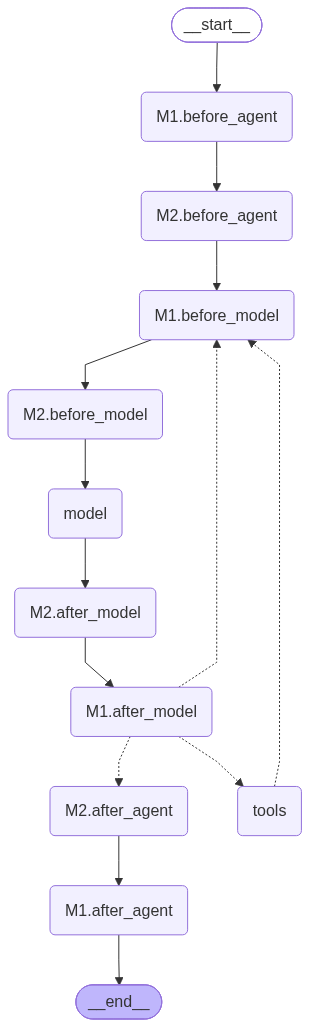

In [16]:
from IPython.display import Image, display
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
from langchain_core.messages import AIMessage, HumanMessage


class FakeToolModel(GenericFakeChatModel):
    """假模型：按顺序返回预先写好的消息，不调用任何接口。"""

    def bind_tools(self, tools, **kwargs):
        return self  # create_agent 会调用 bind_tools，假模型直接返回自身

    def _generate(self, *args, **kwargs):
        print("        model 节点：调用模型")
        return super()._generate(*args, **kwargs)


@tool
def get_weather(city: str) -> str:
    """查询指定城市天气"""
    print(f"        tools 节点：执行 get_weather({city})")
    return f"{city}今天晴"


class OrderMiddleware(AgentMiddleware):
    """在每个 node-style hook 中打印自己的名字"""

    def __init__(self, tag: str):
        super().__init__()
        self.tag = tag

    @property
    def name(self) -> str:
        return self.tag  # 同一个类要创建两个实例，让它们的 name 不同，否则 create_agent 会报错

    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"{self.tag}.before_agent")
        return None

    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"    {self.tag}.before_model")
        return None

    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"    {self.tag}.after_model")
        return None

    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"{self.tag}.after_agent")
        return None


fake_model = FakeToolModel(messages=iter([
    AIMessage("", tool_calls=[{"name": "get_weather", "args": {"city": "北京"}, "id": "call_1"}]),  # 第 1 次：调用工具
    AIMessage("北京今天晴。"),                                                                      # 第 2 次：最终回答
]))

order_agent = create_agent(
    model=fake_model,
    tools=[get_weather],
    middleware=[OrderMiddleware("M1"), OrderMiddleware("M2")],
)
order_agent.invoke({"messages": [HumanMessage("北京天气怎么样？")]})

display(Image(order_agent.get_graph().draw_mermaid_png()))

分析：

1. `before_agent`、`after_agent` 只执行了一次；`before_model`、`after_model` 各执行了两次，因为模型被调用了两次：第一次要求调用工具，工具执行完回到 `M1.before_model`，第二次给出最终回答。
2. before 类 hook 按 M1 → M2 执行，after 类 hook 按 M2 → M1 执行。流程图中也能看出来：`model` 之后先到 `M2.after_model`，再到 `M1.after_model`。
3. 流程图中的虚线表示“按条件选择”的边：`M1.after_model` 根据模型有没有调用工具，决定去 `tools` 还是 `M2.after_agent`。`M1.after_model` 直接回到 `M1.before_model` 的那条虚线用于 `jump_to` 跳回模型等特殊情况，平时不会走。
4. 回头看 5.3.1 的装饰器例子：4 个中间件各只有一种 hook，所以执行顺序完全由 hook 的种类决定，和它们在列表中的位置无关。

### 5.3.7 小结

**node-style hook 的写法模板：**

```python
@before_model                                       # ① 选时机：before_agent / before_model / after_model / after_agent
def my_hook(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    # ② 读：state["messages"] 等当前状态；runtime.context 等运行信息
    # ③ 写：返回字典，只写要修改的字段；不修改就返回 None
    return None
```

**为什么这样定义：**

1. hook 是框架调用的：`create_agent` 把它变成流程图中的一个节点，运行到这个节点时，框架传入 `state`（当前状态）和 `runtime`（运行信息），再把返回的字典按合并规则合并进 state。所以参数和返回值都由框架规定。
2. `AgentMiddleware` 是所有中间件的父类，提供 6 个 hook 的默认版本和 `name`、`tools`、`state_schema` 等属性。`create_agent` 通过“子类的方法是否和父类不同”判断你实现了哪些 hook。装饰器写法只是自动生成了这个子类，并创建了实例，所以传给 `middleware=` 时不加括号；类写法要自己写 `MyMiddleware()`。

**常见错误（langchain 1.4.2 实测）：**

| 错误写法 | 结果 |
|---|---|
| 装饰器函数只写一个参数：`def f(state)` | `TypeError: f() takes 1 positional argument but 2 were given` |
| 类方法的第二个参数不叫 `runtime`：`def before_model(self, state, rt)` | `TypeError: ... missing 1 required positional argument: 'rt'` |
| 类方法名拼错：`def before_models(...)` | 不报错，但永远不会执行 |
| 不继承 `AgentMiddleware` | `create_agent` 报 `AttributeError` |
| 类写法传入时忘了加括号：`middleware=[MyMiddleware]` | `AttributeError: type object 'type' has no attribute 'wrap_tool_call'` |
| 装饰器写法传入时多加了括号：`middleware=[before_model_middleware()]` | `TypeError: 'before_model_middleware' object is not callable` |
| 同一个类的两个实例放进同一个 Agent | `AssertionError: Please remove duplicate middleware instances.` |
| 返回字符串等非字典 | `InvalidUpdateError: Expected dict, got ...` |
| 返回 state 中不存在的键：`{"foo": 1}` | 不报错，但被丢弃 |
| 返回 `jump_to`，但没有声明 `can_jump_to` | 不报错，通常也不会跳转（有工具时，最后执行的 after_model 例外，见 5.3.4） |
| 直接修改 `state` 中的对象，返回 `None` | 能看到效果，但框架不知道发生了修改，还会改到调用方传入的消息对象（见 5.3.4） |